In [0]:
import warnings
warnings.filterwarnings('ignore')

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import *

from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    average_precision_score,
    recall_score,
    precision_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb

from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [0]:
pd.set_option('display.max_colwidth', None)

In [0]:
COLUNA_ALVO = 'Class'
RANDOM_STATE = 42

In [0]:
df = pd.read_csv('./creditcard.csv', delimiter=',')
print("Shape:", df.shape)
print("Columns:", df.columns)

X_full = df.drop(COLUNA_ALVO, axis=1)
y_full = df[COLUNA_ALVO]

Shape: (284807, 31)
Columns: Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [0]:
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)

## Grids e modelos

In [0]:
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), ['Time', 'Amount'])
    ],
    remainder='passthrough'
)

In [0]:
param_grid_rfc = {
    'model__n_estimators': [100, 300],
    'model__max_depth': [10, None],
    'model__min_samples_leaf': [1, 5]
}

param_grid_lr = {
    'model__penalty': ['l1', 'l2'],
    'model__C': [0.01, 0.1],
    'model__solver': ['liblinear', 'saga']
}

param_grid_knn = {
    'model__n_neighbors': [3, 5]
}

param_grid_xgb = {
    "model__max_depth": [10, 50],
    "model__learning_rate": [0.1, 0.01],
    "model__n_estimators": [30, 500]
}

param_grid_nb = {
    'model__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

In [0]:
pipeline_rfc_oversampling = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', SMOTE(random_state=RANDOM_STATE)),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

pipeline_lr_oversampling = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', SMOTE(random_state=RANDOM_STATE)),
    ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=500, n_jobs=-1))
])

pipeline_knn_oversampling = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', SMOTE(random_state=RANDOM_STATE)),
    ('model', KNeighborsClassifier(n_jobs=-1))
])

pipeline_xgb_oversampling = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', SMOTE(random_state=RANDOM_STATE)),
    ('model', xgb.XGBClassifier(seed=RANDOM_STATE, n_jobs=-1))
])

pipeline_nb_oversampling = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', SMOTE(random_state=RANDOM_STATE)),
    ('model', GaussianNB())
])

In [0]:
models_to_run_oversampling = {
    'NaiveBayes': {
        'estimator': pipeline_nb_oversampling,
        'param_grid': param_grid_nb
    },
    'RandomForest': {
        'estimator': pipeline_rfc_oversampling,
        'param_grid': param_grid_rfc
    },
    'LogisticRegression': {
        'estimator': pipeline_lr_oversampling,
        'param_grid': param_grid_lr
    },
    'KNN': {
        'estimator': pipeline_knn_oversampling,
        'param_grid': param_grid_knn
    },
    'XGBoost': {
        'estimator': pipeline_xgb_oversampling,
        'param_grid': param_grid_xgb
    }
}

In [0]:
def run_single_model_nested_cv(
    estimator,
    param_grid,
    X,
    y,
    scoring=['accuracy', 'recall', 'precision', 'f1', 'roc_auc'],
    n_splits_outer=3,
    n_splits_inner=3,
    scoring_grid_search='f1',
    random_state=RANDOM_STATE):
    
    cv_inner = StratifiedKFold(n_splits=n_splits_inner, shuffle=True, random_state=random_state)
    cv_outer = StratifiedKFold(n_splits=n_splits_outer, shuffle=True, random_state=random_state)

    search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=scoring_grid_search,
        cv=cv_inner,
        refit=True,
        n_jobs=1
    )

    output_ncv = cross_validate(
        estimator=search,
        X=X,
        y=y,
        scoring=scoring,
        cv=cv_outer,
        n_jobs=-1,
        return_estimator=True,
        return_train_score=True
    )

    df_results = pd.DataFrame(output_ncv)

    metrics_cols = [col for col in df_results.columns if col.startswith('test_')]
    summary = df_results[metrics_cols].agg(['mean', 'std']).round(3)

    return df_results, summary
    

In [0]:
all_results = []
all_summaries = []

for model_name, config in models_to_run_oversampling.items():
    print(f"Rodando modelo: {model_name}")
    
    df_model_results, df_model_summary = run_single_model_nested_cv(
        estimator=config['estimator'],
        param_grid=config['param_grid'],
        X=X_train,
        y=y_train
    )
    
    df_model_results['model'] = model_name
    df_model_summary['model'] = model_name

    all_results.append(df_model_results)
    all_summaries.append(df_model_summary)

final_results_df = pd.concat(all_results, ignore_index=True)
final_results_df['best_params'] = final_results_df['estimator'].apply(lambda est: est.best_params_)
final_summary_df = pd.concat(all_summaries, keys=[key for key in models_to_run_oversampling.keys()])

Rodando modelo: NaiveBayes
Rodando modelo: RandomForest
Rodando modelo: LogisticRegression
Rodando modelo: KNN
Rodando modelo: XGBoost


In [0]:
final_results_df.sort_values(['model', 'test_f1'], ascending=False)

,fit_time,score_time,estimator,test_accuracy,train_accuracy,test_recall,train_recall,test_precision,train_precision,test_f1,train_f1,test_roc_auc,train_roc_auc,model,best_params
12,284.539818,1.744004,"GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),\n estimator=Pipeline(steps=[('preprocessor',\n ColumnTransformer(remainder='passthrough',\n transformers=[('scaler',\n StandardScaler(),\n ['Time',\n 'Amount'])])),\n ('sampler', SMOTE(random_state=42)),\n ('model',\n XGBClassifier(base_score=None,\n booster=None,\n callbacks=None,\n colsample_bylevel=None,\n colsa...\n max_cat_threshold=None,\n max_cat_to_onehot=None,\n max_delta_step=None,\n max_depth=None,\n max_leaves=None,\n min_child_weight=None,\n missing=nan,\n monotone_constraints=None,\n multi_strategy=None,\n n_estimators=None,\n n_jobs=-1,\n num_parallel_tree=None, ...))]),\n n_jobs=1,\n param_grid={'model__learning_rate': [0.1, 0.01],\n 'model__max_depth': [10, 50],\n 'model__n_estimators': [30, 500]},\n scoring='f1')",0.999355,1.000000,0.810606,1.000000,0.816794,1.000000,0.813688,1.000000,0.985989,1.000000,XGBoost,"{'model__learning_rate': 0.1, 'model__max_depth': 50, 'model__n_estimators': 500}"
14,292.217154,1.737897,"GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),\n estimator=Pipeline(steps=[('preprocessor',\n ColumnTransformer(remainder='passthrough',\n transformers=[('scaler',\n StandardScaler(),\n ['Time',\n 'Amount'])])),\n ('sampler', SMOTE(random_state=42)),\n ('model',\n XGBClassifier(base_score=None,\n booster=None,\n callbacks=None,\n colsample_bylevel=None,\n colsa...\n max_cat_threshold=None,\n max_cat_to_onehot=None,\n max_delta_step=None,\n max_depth=None,\n max_leaves=None,\n min_child_weight=None,\n missing=nan,\n monotone_constraints=None,\n multi_strategy=None,\n n_estimators=None,\n n_jobs=-1,\n num_parallel_tree=None, ...))]),\n n_jobs=1,\n param_grid={'model__learning_rate': [0.1, 0.01],\n 'model__max_depth': [10, 50],\n 'model__n_estimators': [30, 500]},\n scoring='f1')",0.999276,1.000000,0.854962,1.000000,0.756757,1.000000,0.802867,1.000000,0.985099,1.000000,XGBoost,"{'model__learning_rate': 0.1, 'model__max_depth': 50, 'model__n_estimators': 500}"
13,269.334618,1.704453,"GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),\n estimator=Pipeline(steps=[('preprocessor',\n ColumnTransformer(remainder='passthrough',\n transformers=[('scaler',\n StandardScaler(),\n ['Time',\n 'Amount'])])),\n ('sampler', SMOTE(random_state=42)),\n ('model',\n XGBClassifier(base_score=None,\n booster=None,\n callbacks=None,\n colsample_bylevel=None,\n colsa...\n max_cat_threshold=None,\n max_cat_to_onehot=None,\n max_delta_step=None,\n max_depth=None,\n max_leaves=None,\n min_child_weight=None,\n missing=nan,\n monotone_constraints=None,\n multi_strategy=None,\n n_estimators=None,\n n_jobs=-1,\n num_parallel_tree=None, ...))]),\n n_jobs=1,\n param_grid={'model__learning_rate': [0.1, 0.01],\n 'model__max_depth': [10, 50],\n 'model__n_estimators': [30, 500]},\n scoring='f1')",0.999263,1.000000,0.793893,1.000000,0.781955,1.000000,0.787879,1.000000,0.976915,1.000000,XGBoost,"{'model__learning_rate': 0.1, 'model__max_depth': 10, 'model__n_estimators': 500}"
5,1083.777291,0.321830,"GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),\n estimator=Pipeline(steps=[('preprocessor',\n ColumnTransformer(remainder='passthrough',\n transformers=[('scaler',\n StandardScaler(),\n ['Time',\n 'Amount'])])),\n ('sampler', SMOTE(random_state=42)),\n ('model',\n RandomForestClassifier(n_jobs=-1,\n random_state=42))]),\n n_jobs=1,\n param_grid={'model__max_depth': [10, None],\n 'model__min_samples_leaf': [1, 5],\n 'model__n_estimators': [100, 300]},\n scoring='f1')",0.999513,1.000000,0.847328,1.000000,0.867188,1.000000,0.857143,1.000000,0.987613,1.000000,RandomForest,"{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}"
4,1052.315360,2.951437,"GridSearchC

In [0]:
display(final_summary_df)

test_accuracy,test_recall,test_precision,test_f1,test_roc_auc,model
0.976,0.855,0.058,0.109,0.957,NaiveBayes
0.001,0.007,0.002,0.003,0.008,NaiveBayes
0.999,0.805,0.889,0.844,0.981,RandomForest
0.0,0.037,0.027,0.013,0.01,RandomForest
0.974,0.914,0.058,0.109,0.975,LogisticRegression
0.001,0.012,0.001,0.003,0.011,LogisticRegression
0.998,0.827,0.529,0.645,0.918,KNN
0.0,0.032,0.01,0.013,0.018,KNN
0.999,0.82,0.785,0.801,0.983,XGBoost
0.0,0.032,0.03,0.013,0.005,XGBoost


=== Métricas de desempenho ===
F1 Score:     0.6914
Precisão:     0.5793
Recall:       0.8571
ROC AUC:      0.9384


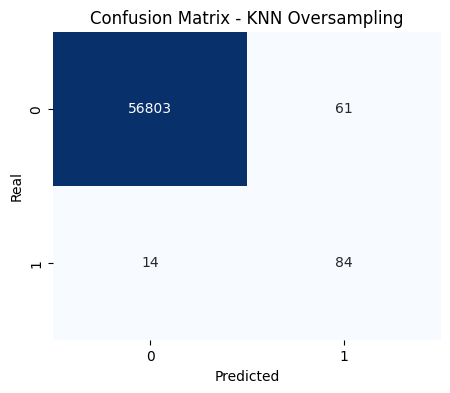

In [0]:
param_grid_knn = {'model__n_neighbors': 3}

pipeline_knn_oversampling.set_params(**param_grid_knn)
pipeline_knn_oversampling.fit(X_train, y_train)

y_pred = pipeline_knn_oversampling.predict(X_test)
y_proba = pipeline_knn_oversampling.predict_proba(X_test)[:, 1]

f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("=== Métricas de desempenho ===")
print(f"F1 Score:     {f1:.4f}")
print(f"Precisão:     {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"ROC AUC:      {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - KNN Oversampling")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.show()

=== Métricas de desempenho ===
F1 Score:     0.8247
Precisão:     0.8333
Recall:       0.8163
ROC AUC:      0.9718


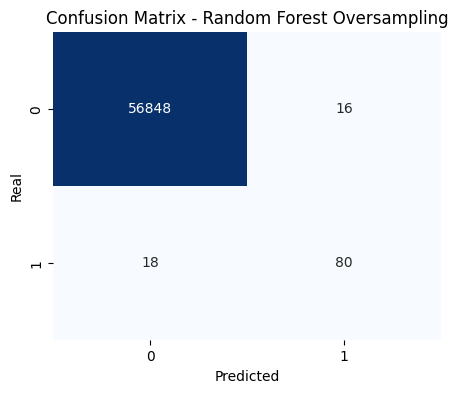

In [0]:
param_grid_rfc = {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}

pipeline_rfc_oversampling.set_params(**param_grid_rfc)
pipeline_rfc_oversampling.fit(X_train, y_train)

y_pred = pipeline_rfc_oversampling.predict(X_test)
y_proba = pipeline_rfc_oversampling.predict_proba(X_test)[:, 1]

f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("=== Métricas de desempenho ===")
print(f"F1 Score:     {f1:.4f}")
print(f"Precisão:     {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"ROC AUC:      {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - Random Forest Oversampling")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.show()

=== Métricas de desempenho ===
F1 Score:     0.8416
Precisão:     0.8173
Recall:       0.8673
ROC AUC:      0.9814


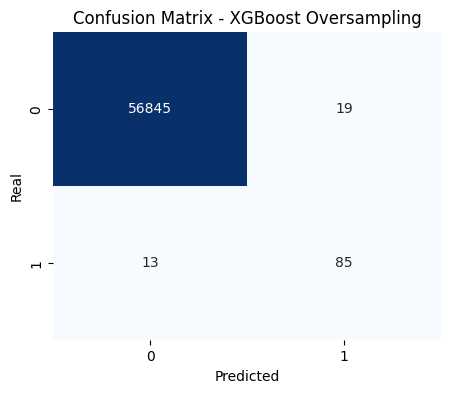

In [0]:
param_grid_xgb = {'model__learning_rate': 0.1, 'model__max_depth': 50, 'model__n_estimators': 500}

pipeline_xgb_oversampling.set_params(**param_grid_xgb)
pipeline_xgb_oversampling.fit(X_train, y_train)

y_pred = pipeline_xgb_oversampling.predict(X_test)
y_proba = pipeline_xgb_oversampling.predict_proba(X_test)[:, 1]

f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("=== Métricas de desempenho ===")
print(f"F1 Score:     {f1:.4f}")
print(f"Precisão:     {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"ROC AUC:      {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - XGBoost Oversampling")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.show()

=== Métricas de desempenho ===
F1 Score:     0.1035
Precisão:     0.0550
Recall:       0.8776
ROC AUC:      0.9644


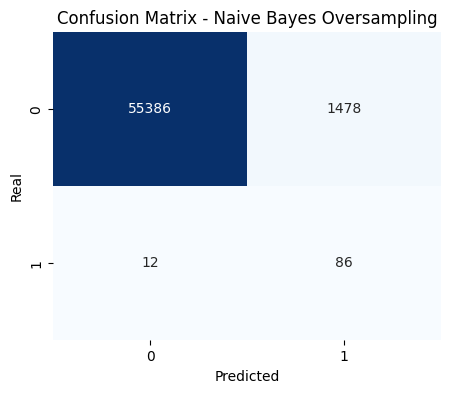

In [0]:
param_grid_nb = {'model__var_smoothing': 1e-09}

pipeline_nb_oversampling.set_params(**param_grid_nb)
pipeline_nb_oversampling.fit(X_train, y_train)

y_pred = pipeline_nb_oversampling.predict(X_test)
y_proba = pipeline_nb_oversampling.predict_proba(X_test)[:, 1]

f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("=== Métricas de desempenho ===")
print(f"F1 Score:     {f1:.4f}")
print(f"Precisão:     {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"ROC AUC:      {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - Naive Bayes Oversampling")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.show()

=== Métricas de desempenho ===
F1 Score:     0.1104
Precisão:     0.0587
Recall:       0.9184
ROC AUC:      0.9707


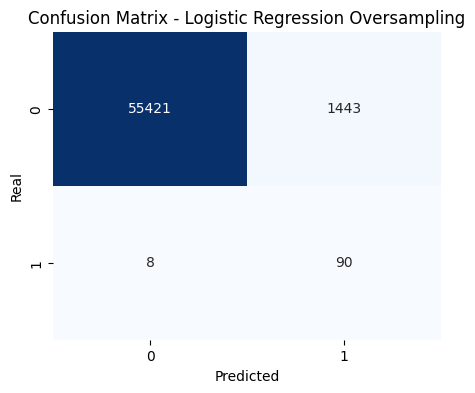

In [0]:
param_grid_lr = {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

pipeline_lr_oversampling.set_params(**param_grid_lr)
pipeline_lr_oversampling.fit(X_train, y_train)

y_pred = pipeline_lr_oversampling.predict(X_test)
y_proba = pipeline_lr_oversampling.predict_proba(X_test)[:, 1]

f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("=== Métricas de desempenho ===")
print(f"F1 Score:     {f1:.4f}")
print(f"Precisão:     {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"ROC AUC:      {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - Logistic Regression Oversampling")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.show()